In [85]:
#!pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy xgboost
#!pip install missingno

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

In [4]:
# to visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

In [5]:
# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

In [6]:
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor

In [7]:
from xgboost import XGBClassifier

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# 1. EDA / Базовое знакомство с датасетом

In [9]:
# load the data from a csv file placed locally in your pc
df = pd.read_csv('input/heart_disease_uci.csv') # -> use your pc's file path to import the csv dataset
# print the first few rows of the dataframe
df.head()

,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
df.tail()

,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [18]:
df.sample(10, random_state=0)

,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
306,307,30,Female,Hungary,typical angina,170.0,237.0,False,st-t abnormality,170.0,False,0.0,NaN,NaN,fixed defect,0
711,712,68,Male,Switzerland,asymptomatic,135.0,0.0,False,st-t abnormality,120.0,True,0.0,upsloping,NaN,reversable defect,3
298,299,45,Male,Cleveland,typical angina,110.0,264.0,False,normal,132.0,False,1.2,flat,0.0,reversable defect,1
466,467,55,Male,Hungary,non-anginal,120.0,220.0,False,lv hypertrophy,134.0,False,0.0,NaN,NaN,NaN,0
253,254,51,Female,Cleveland,non-anginal,120.0,295.0,False,lv hypertrophy,157.0,False,0.6,upsloping,0.0,normal,0
230,231,52,Female,Cleveland,non-anginal,136.0,196.0,False,lv hypertrophy,169.0,False,0.1,flat,0.0,normal,0
908,909,74,Male,VA Long Beach,asymptomatic,155.0,310.0,False,normal,112.0,True,1.5,downsloping,NaN,NaN,2
14,15,52,Male,Cleveland,non-anginal,172.0,199.0,True,normal,162.0,False,0.5,upsloping,0.0,reversable defect,0
202,203,57,Male,Cleveland,non-anginal,150.0,126.0,True,normal,173.0,False,0.2,upsloping,1.0,reversable defect,0
31,32,60,Male,Cleveland,asymptomatic,117.0,230.0,True,normal,160.0,True,1.4,upsloping,2.0,reversable defect,2


In [12]:
df.shape

(920, 16)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   gender    920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [15]:
df.dtypes

id            int64
age           int64
gender          str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [11]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [14]:
# сводка по всем колонкам, включая категориальные
df.describe(include='all').T 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
gender,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [16]:
# сколько уникальных значений в каждом столбце
df.nunique() 

id          920
age          50
gender        2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64

# 2. Пропуски

In [31]:
# Сколько пропусков и их доля
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
pd.DataFrame({'missing': missing, 'pct_%': missing_pct})

,missing,pct_%
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
thalch,55,5.98
exang,55,5.98
chol,30,3.26
restecg,2,0.22


## Визуализация пропусков

In [36]:
import missingno as msno   # pip install missingno

<Axes: >

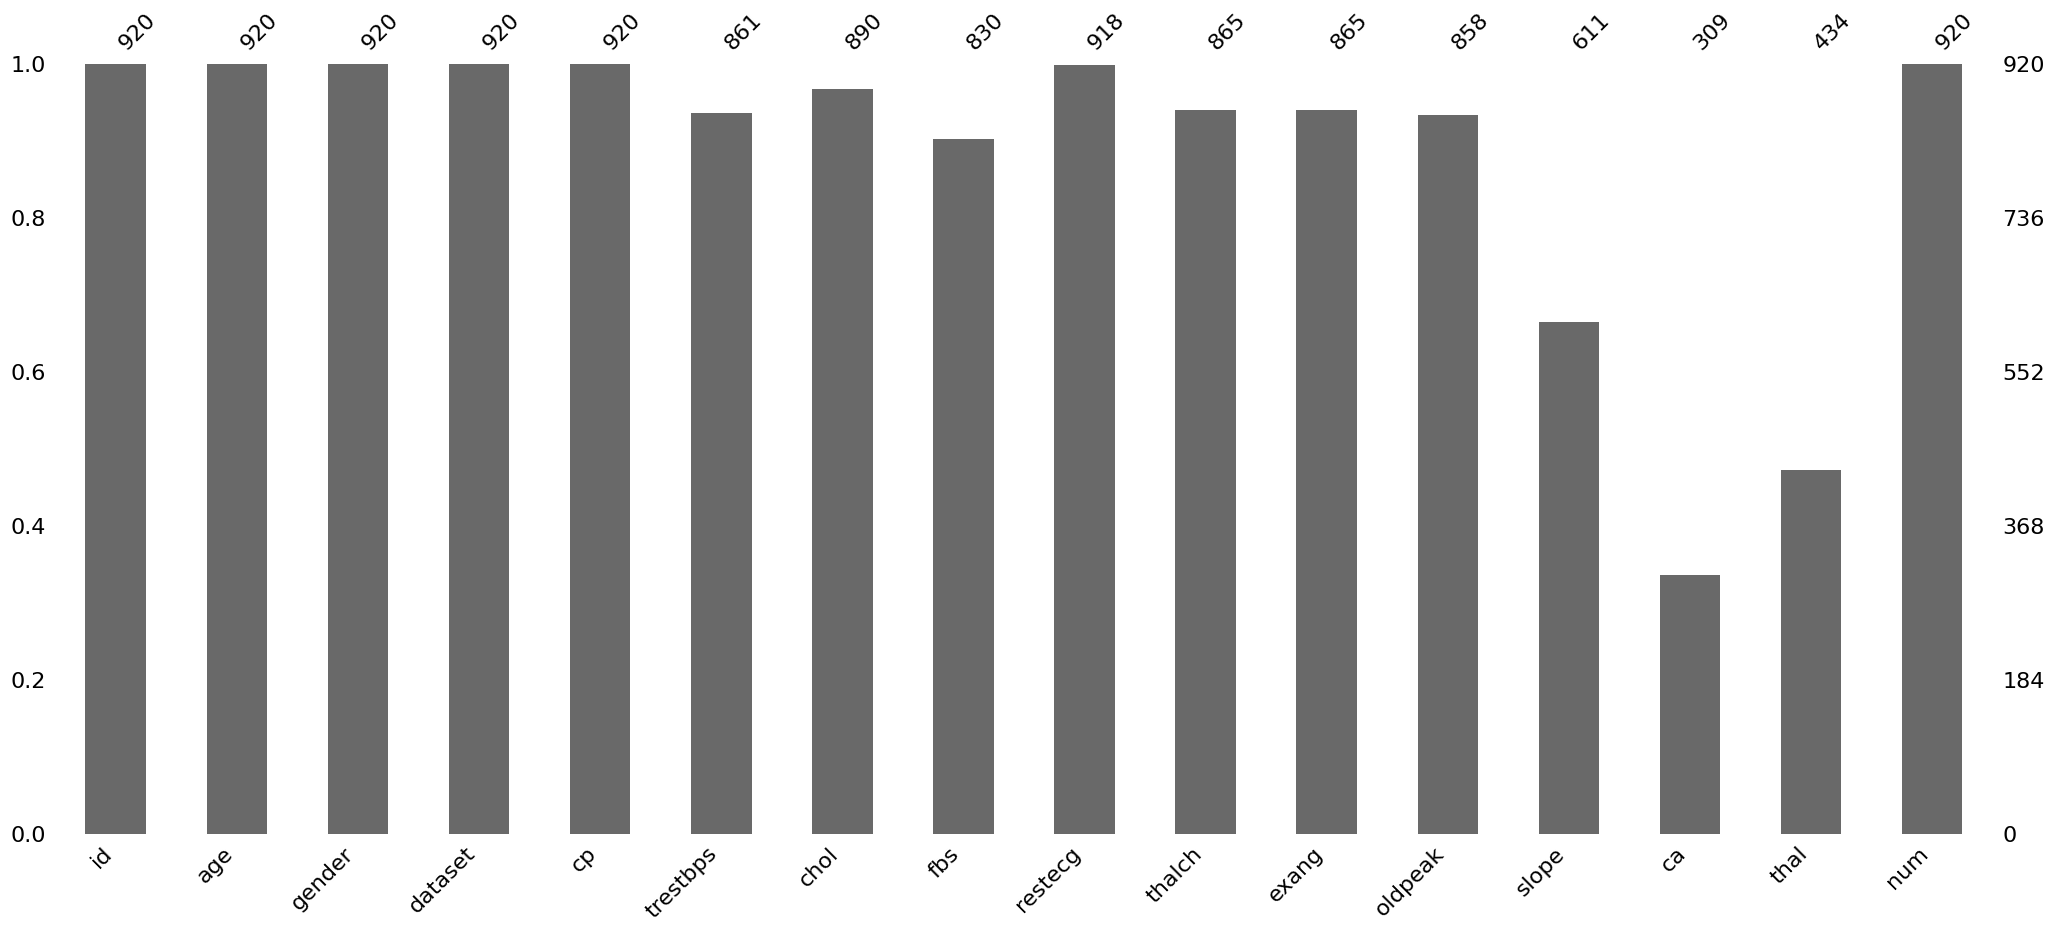

In [37]:
msno.bar(df)

<Axes: >

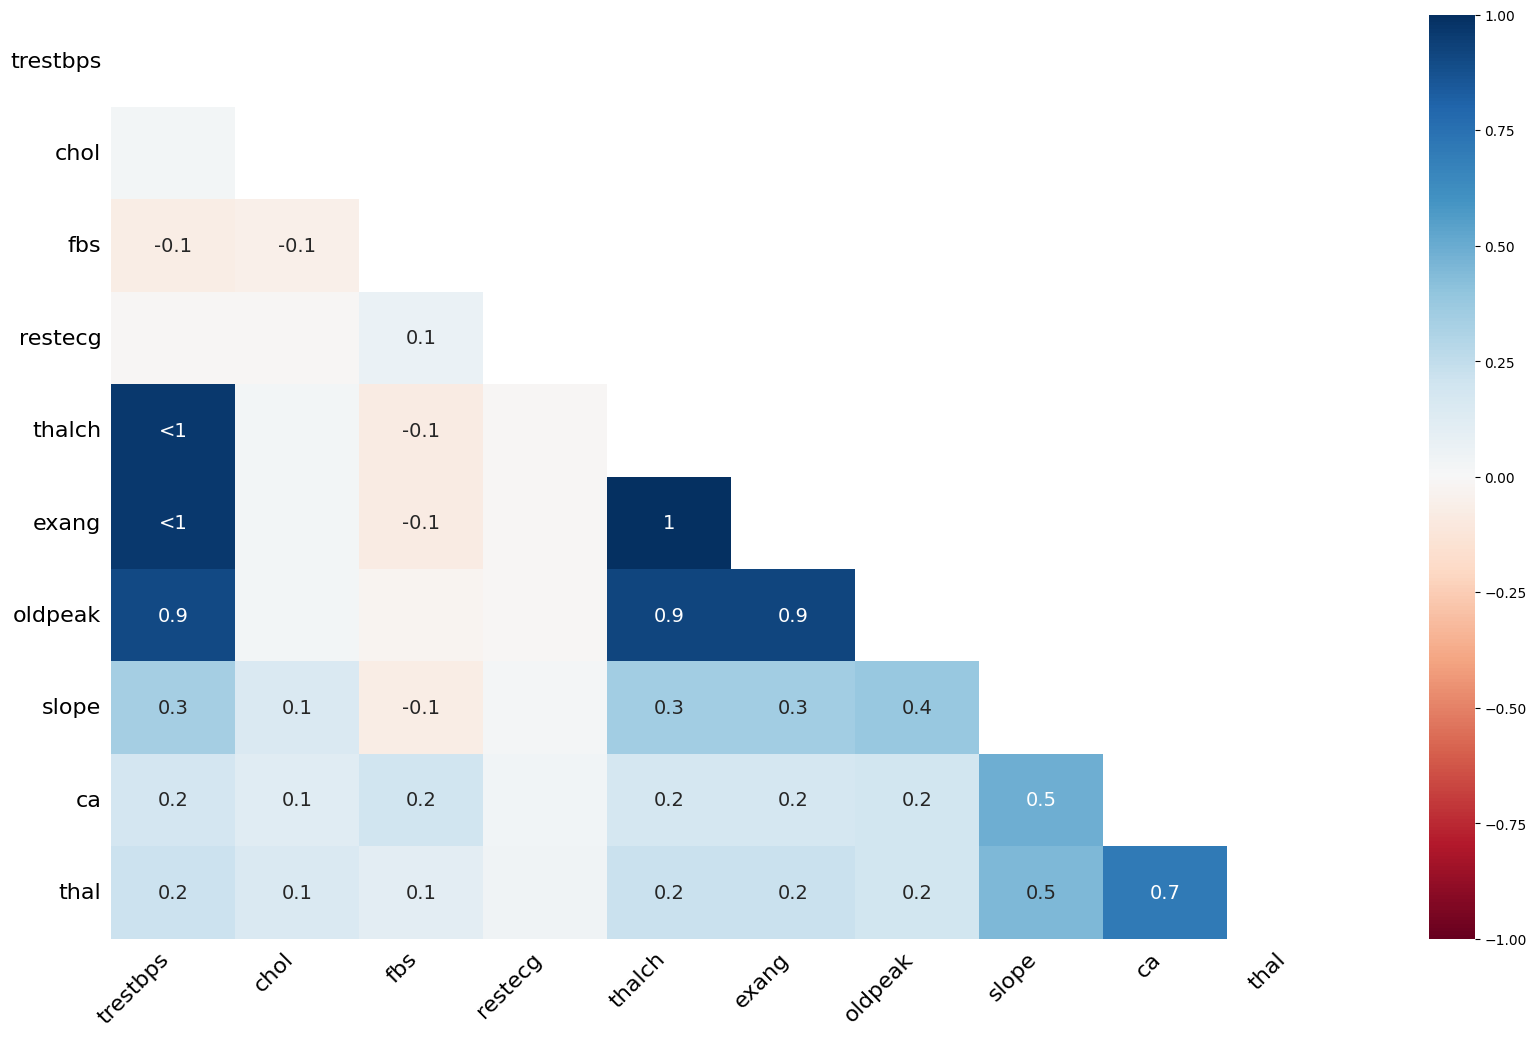

In [38]:
msno.heatmap(df)

In [39]:
# Пропуски в разрезе dataset — критично для этого датасета
df.groupby('dataset').apply(lambda x: x.isna().mean() * 100).round(2)

,id,age,gender,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
dataset,,,,,,,,,,,,,,,
Cleveland,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.33,1.64,0.99,0.0
Hungary,0.0,0.0,0.0,0.0,0.34,7.85,2.73,0.34,0.34,0.34,0.00,64.51,98.98,90.44,0.0
Switzerland,0.0,0.0,0.0,0.0,1.63,0.00,60.98,0.81,0.81,0.81,4.88,13.82,95.93,42.28,0.0
VA Long Beach,0.0,0.0,0.0,0.0,28.00,3.50,3.50,0.00,26.50,26.50,28.00,51.00,99.00,83.00,0.0


# 3. Дубликаты и уникальность

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['id'].duplicated().sum()

np.int64(0)

In [28]:
df['id'].is_unique

True

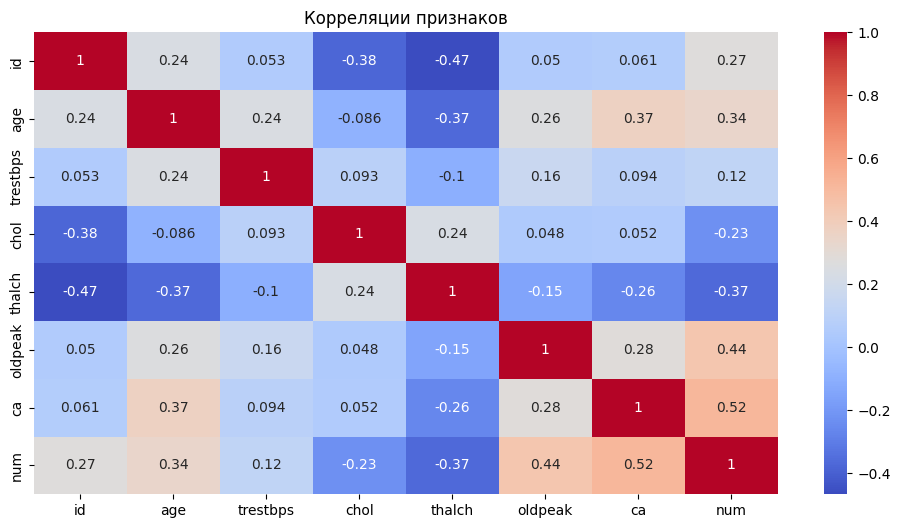

In [9]:
# Seaborn: корреляционная матрица
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляции признаков')
plt.show()

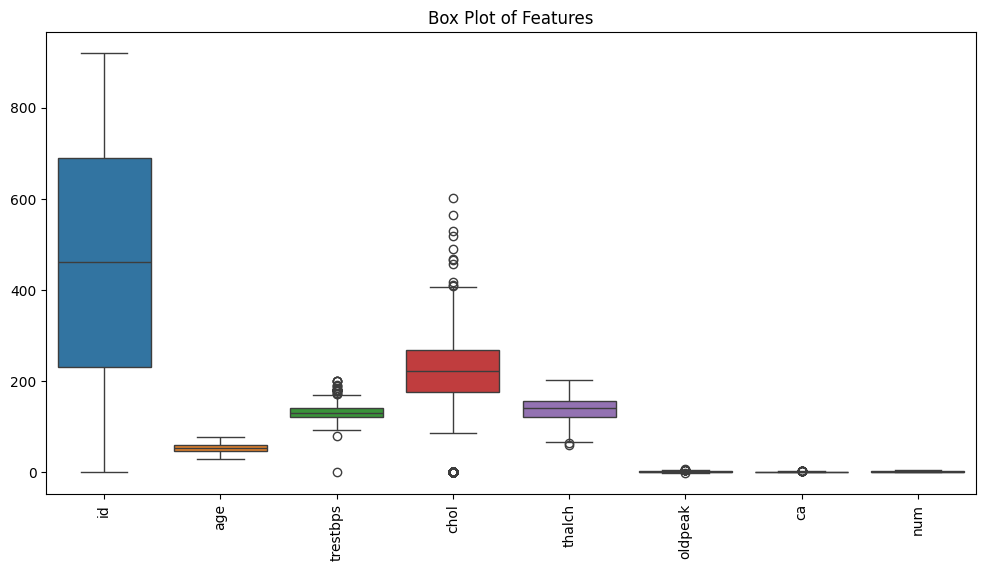

In [10]:
# Seaborn: boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title('Box Plot of Features')
plt.show()

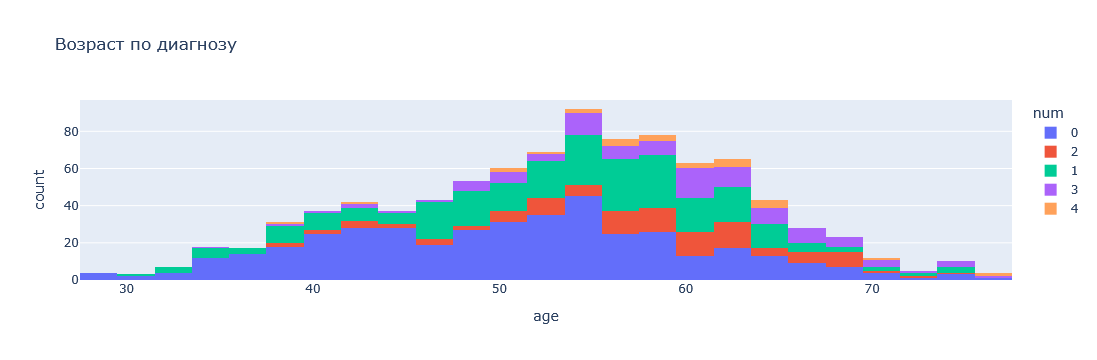

In [11]:
# Plotly Express: интерактивная гистограмма
px.histogram(df, x='age', color='num', title='Возраст по диагнозу').show()

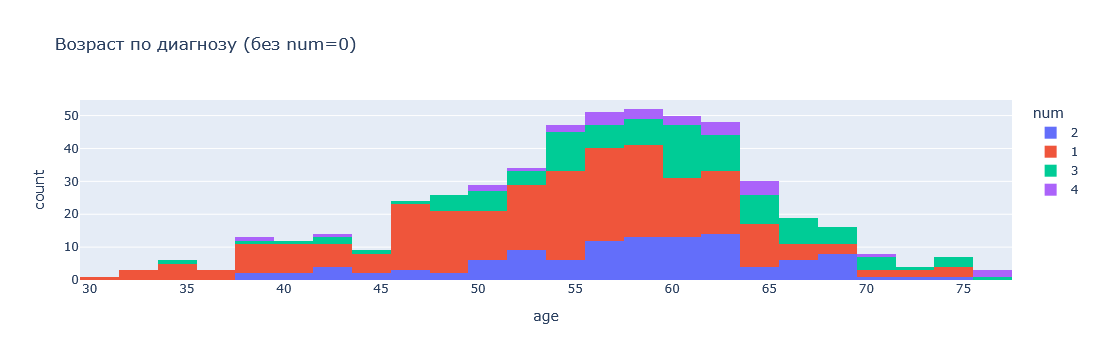

In [14]:
px.histogram(
    df.query('num != 0'),
    x='age',
    color='num',
    title='Возраст по диагнозу (без num=0)'
).show()

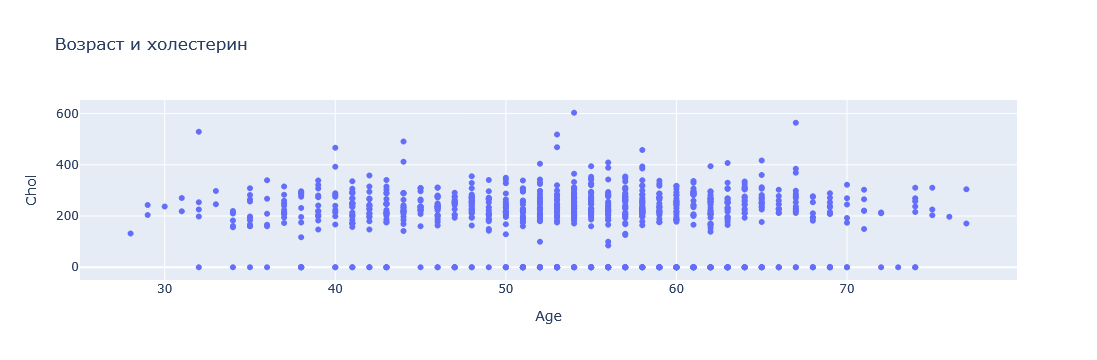

In [12]:
# Plotly Graph Objects: scatter
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['age'], y=df['chol'], mode='markers', name='Пациенты'))
fig.update_layout(title='Возраст и холестерин', xaxis_title='Age', yaxis_title='Chol')
fig.show()

# 4. Анализ целевой переменной (num)

## Распределение классов

In [41]:
df['num'].value_counts().sort_index()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [42]:
df['num'].value_counts(normalize=True).sort_index().round(3)

num
0    0.447
1    0.288
2    0.118
3    0.116
4    0.030
Name: proportion, dtype: float64

## Бинарная версия: есть болезнь или нет

In [44]:
df['target'] = (df['num'] > 0).astype(int)
df['target'].value_counts(normalize=True)

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64

## Countplot

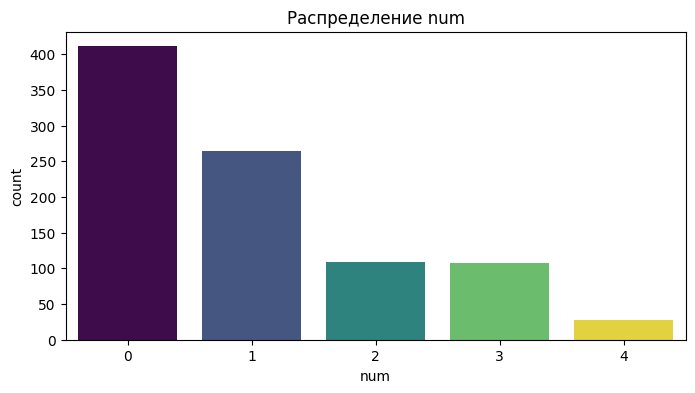

In [46]:
plt.figure(figsize=(8, 4))
sns.countplot(x='num', data=df, hue='num', palette='viridis', legend=False)
plt.title('Распределение num')
plt.show()

## Разрез по источникам

In [48]:
pd.crosstab(df['dataset'], df['num'], normalize='index').round(3)

num,0,1,2,3,4
dataset,,,,,
Cleveland,0.543,0.181,0.118,0.115,0.043
Hungary,0.638,0.362,0.000,0.000,0.000
Switzerland,0.065,0.390,0.260,0.244,0.041
VA Long Beach,0.255,0.280,0.205,0.210,0.050


In [49]:
pd.crosstab(df['dataset'], df['num'])

num,0,1,2,3,4
dataset,,,,,
Cleveland,165,55,36,35,13
Hungary,187,106,0,0,0
Switzerland,8,48,32,30,5
VA Long Beach,51,56,41,42,10


# 5. Анализ категориальных признаков

In [51]:
cat_cols = ['gender', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

## Уникальные значения

In [52]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
dataset: <StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str
cp: <StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str
fbs: [True False nan]
restecg: <StringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
exang: [False True nan]
slope: <StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
thal: <StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str


## Countplot по каждому

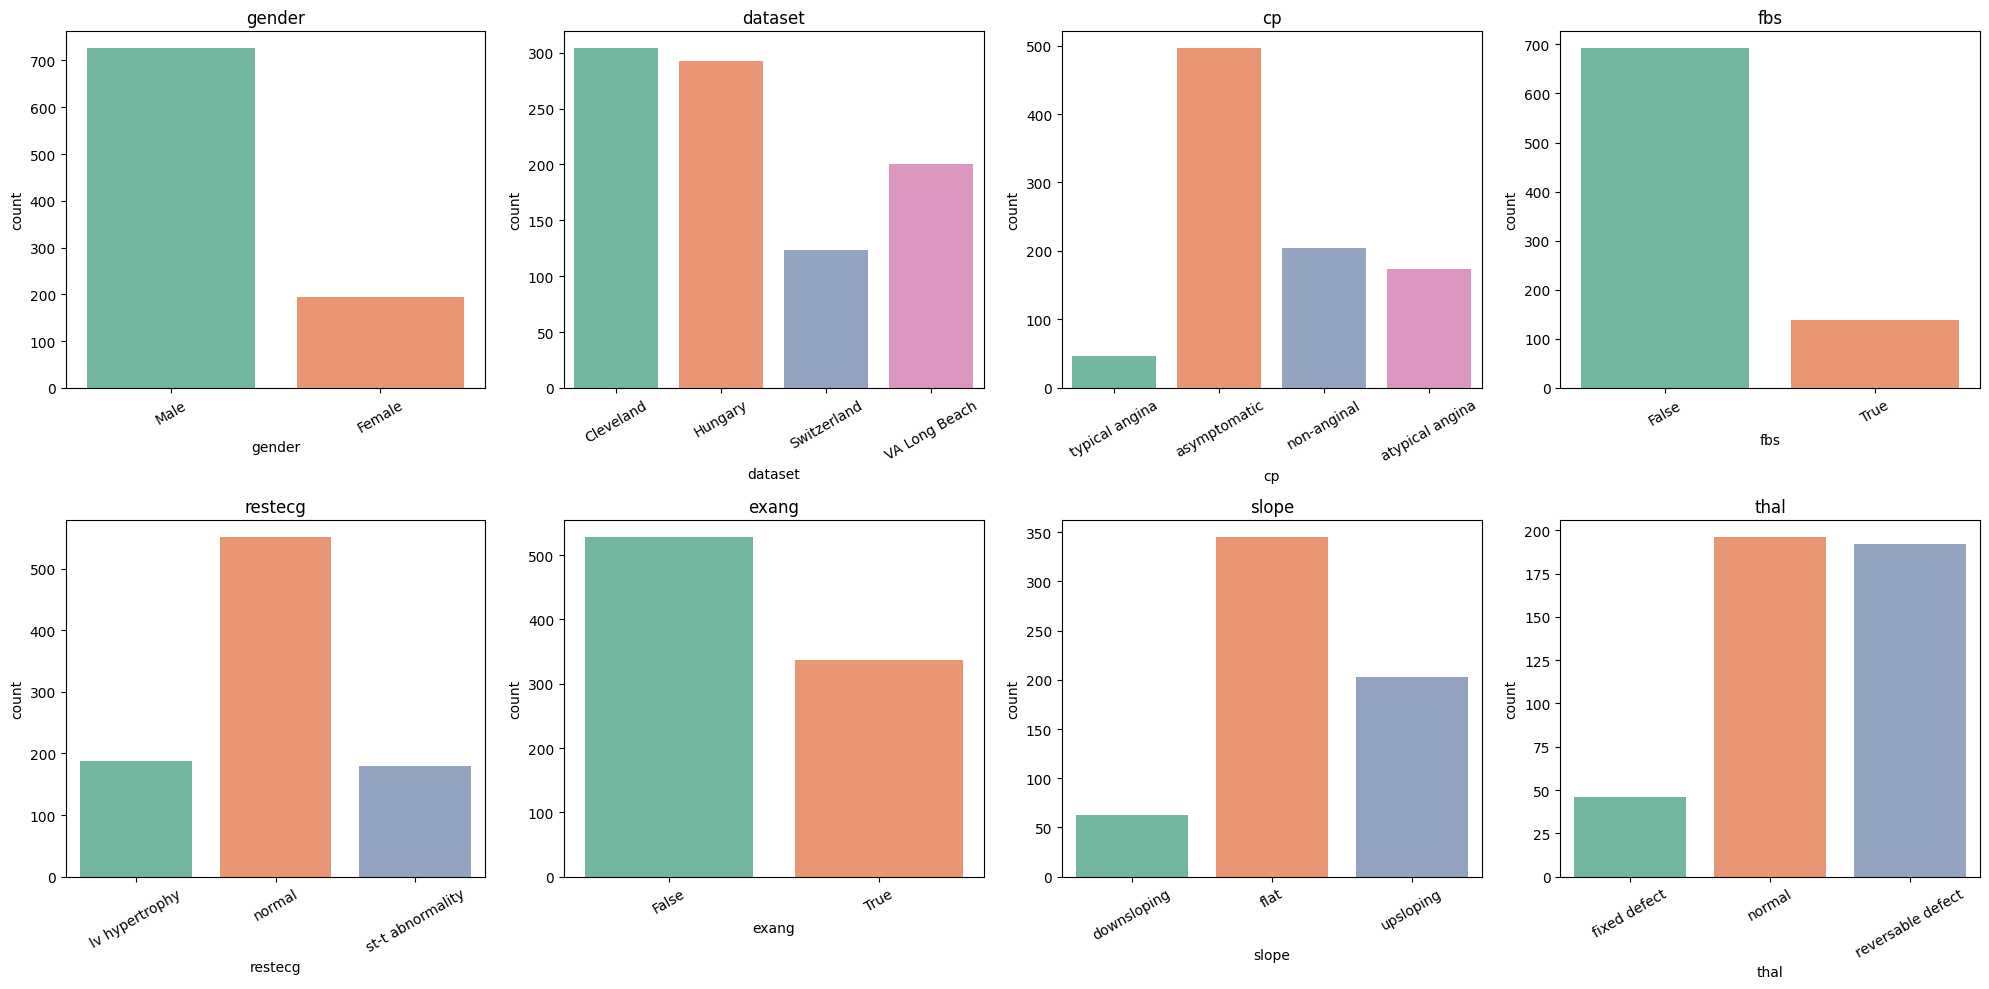

In [55]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(x=col, data=df, ax=ax, hue=col, palette='Set2', legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Взаимосвязь категориальных признаков с целевой

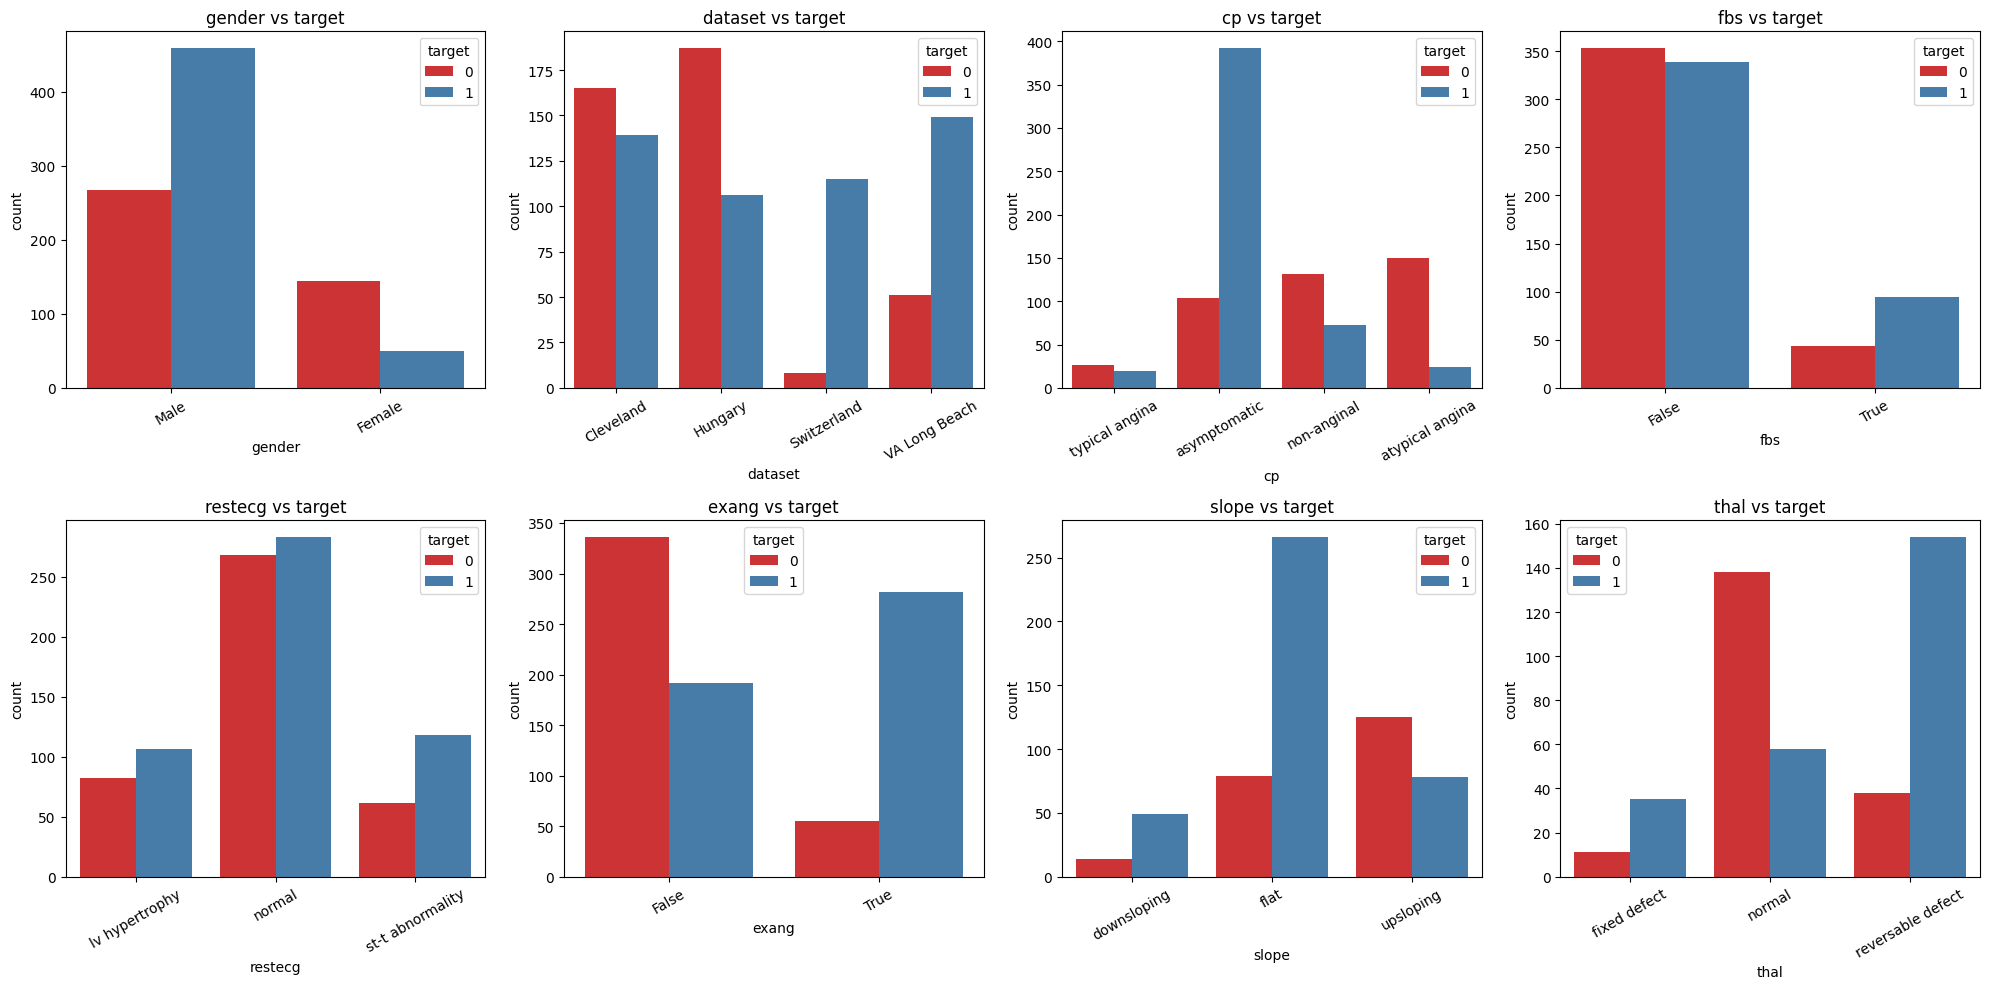

In [57]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(x=col, hue='target', data=df, ax=ax, palette='Set1')
    ax.set_title(f'{col} vs target')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# 6. Анализ числовых признаков

In [59]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

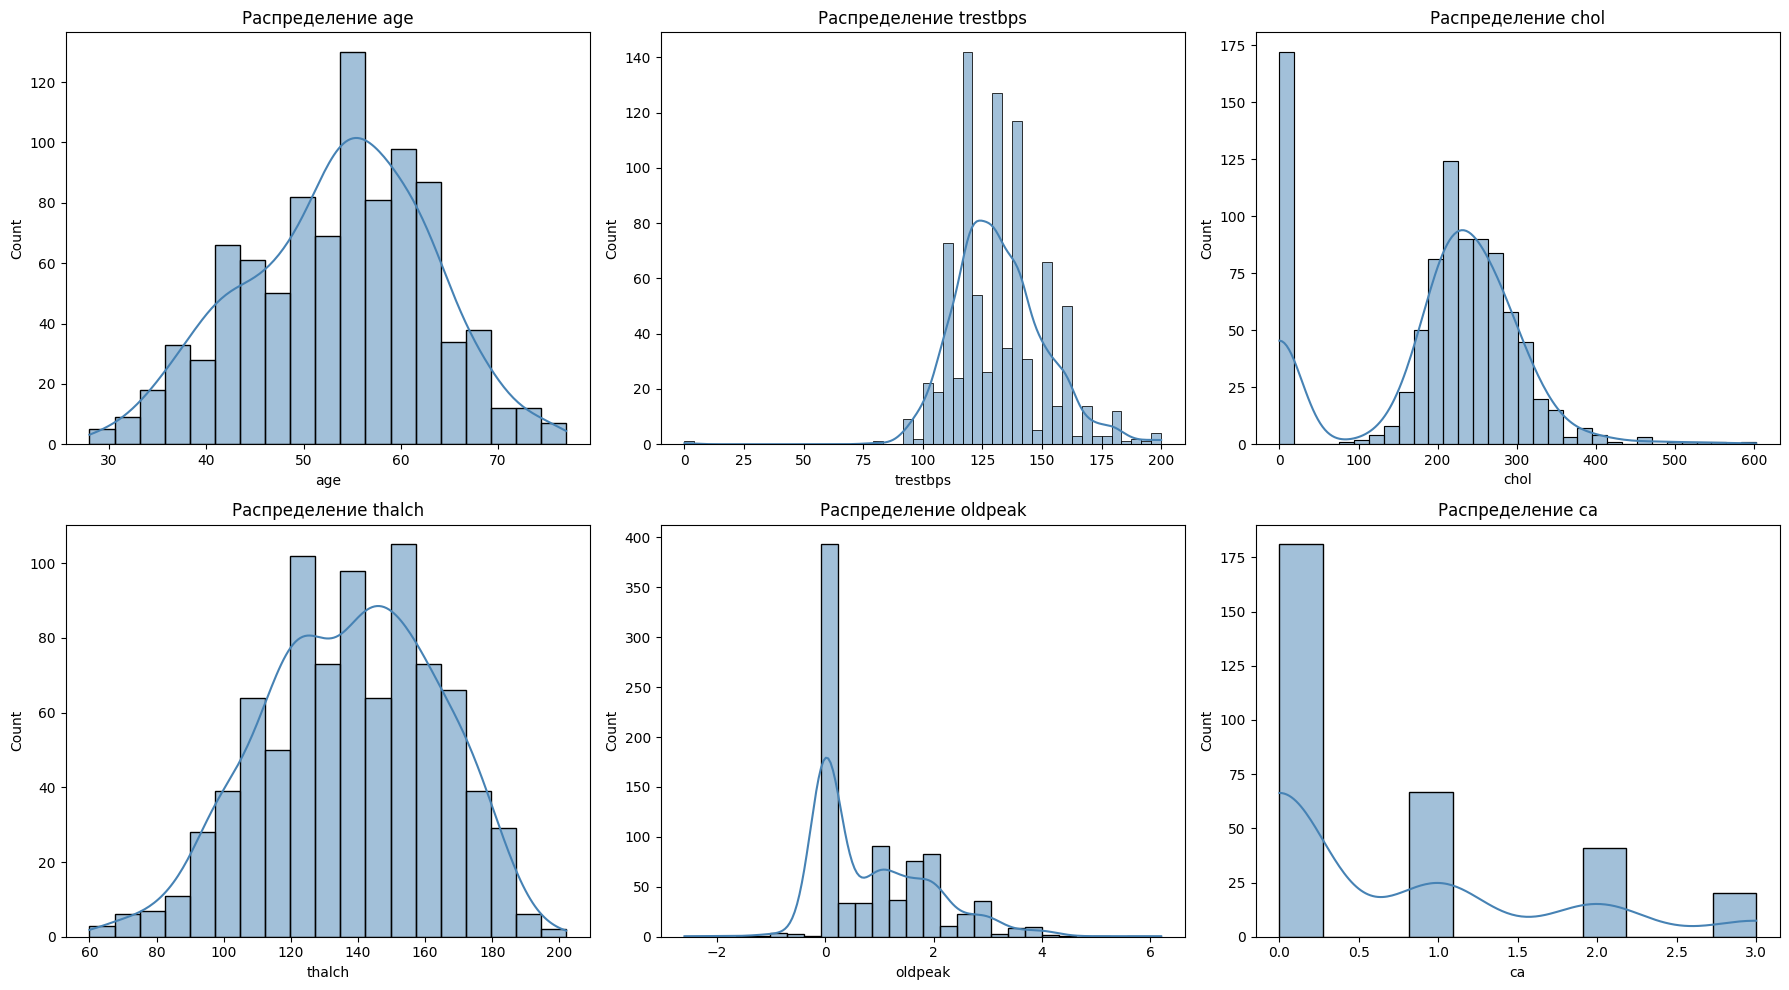

In [60]:
# Распределения
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

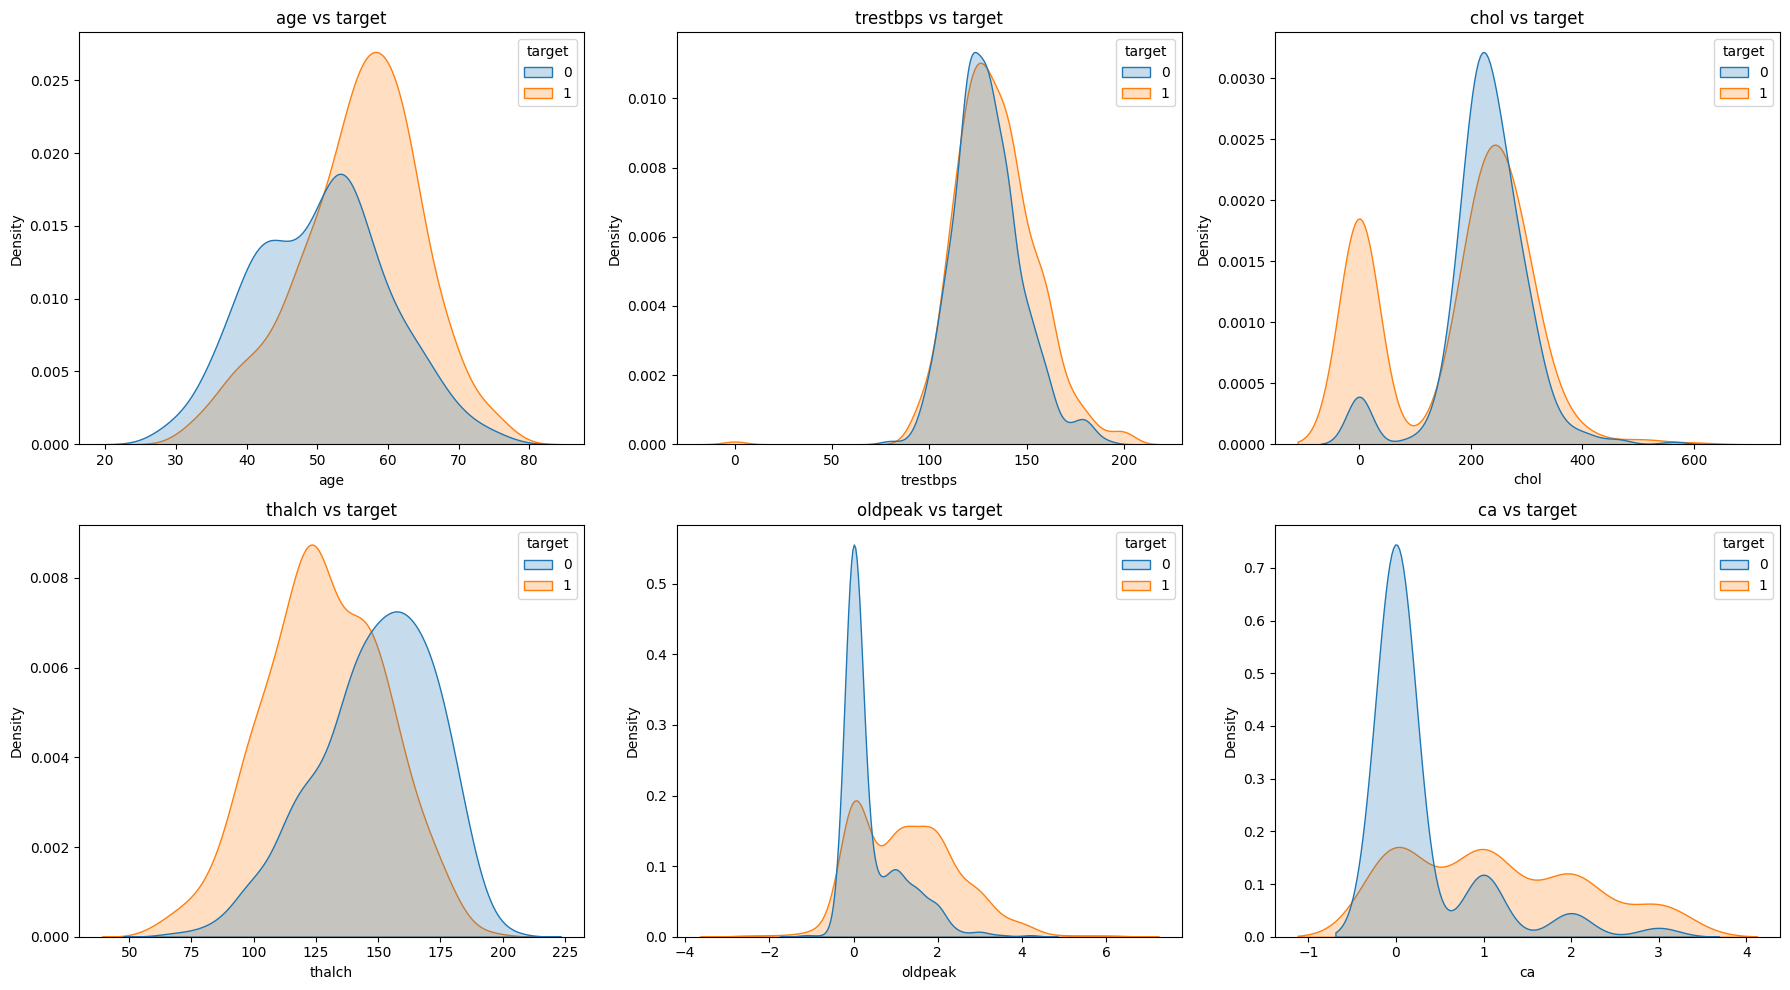

In [61]:
# KDE с раскраской по target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=df, x=col, hue='target', fill=True, ax=ax)
    ax.set_title(f'{col} vs target')
plt.tight_layout()
plt.show()

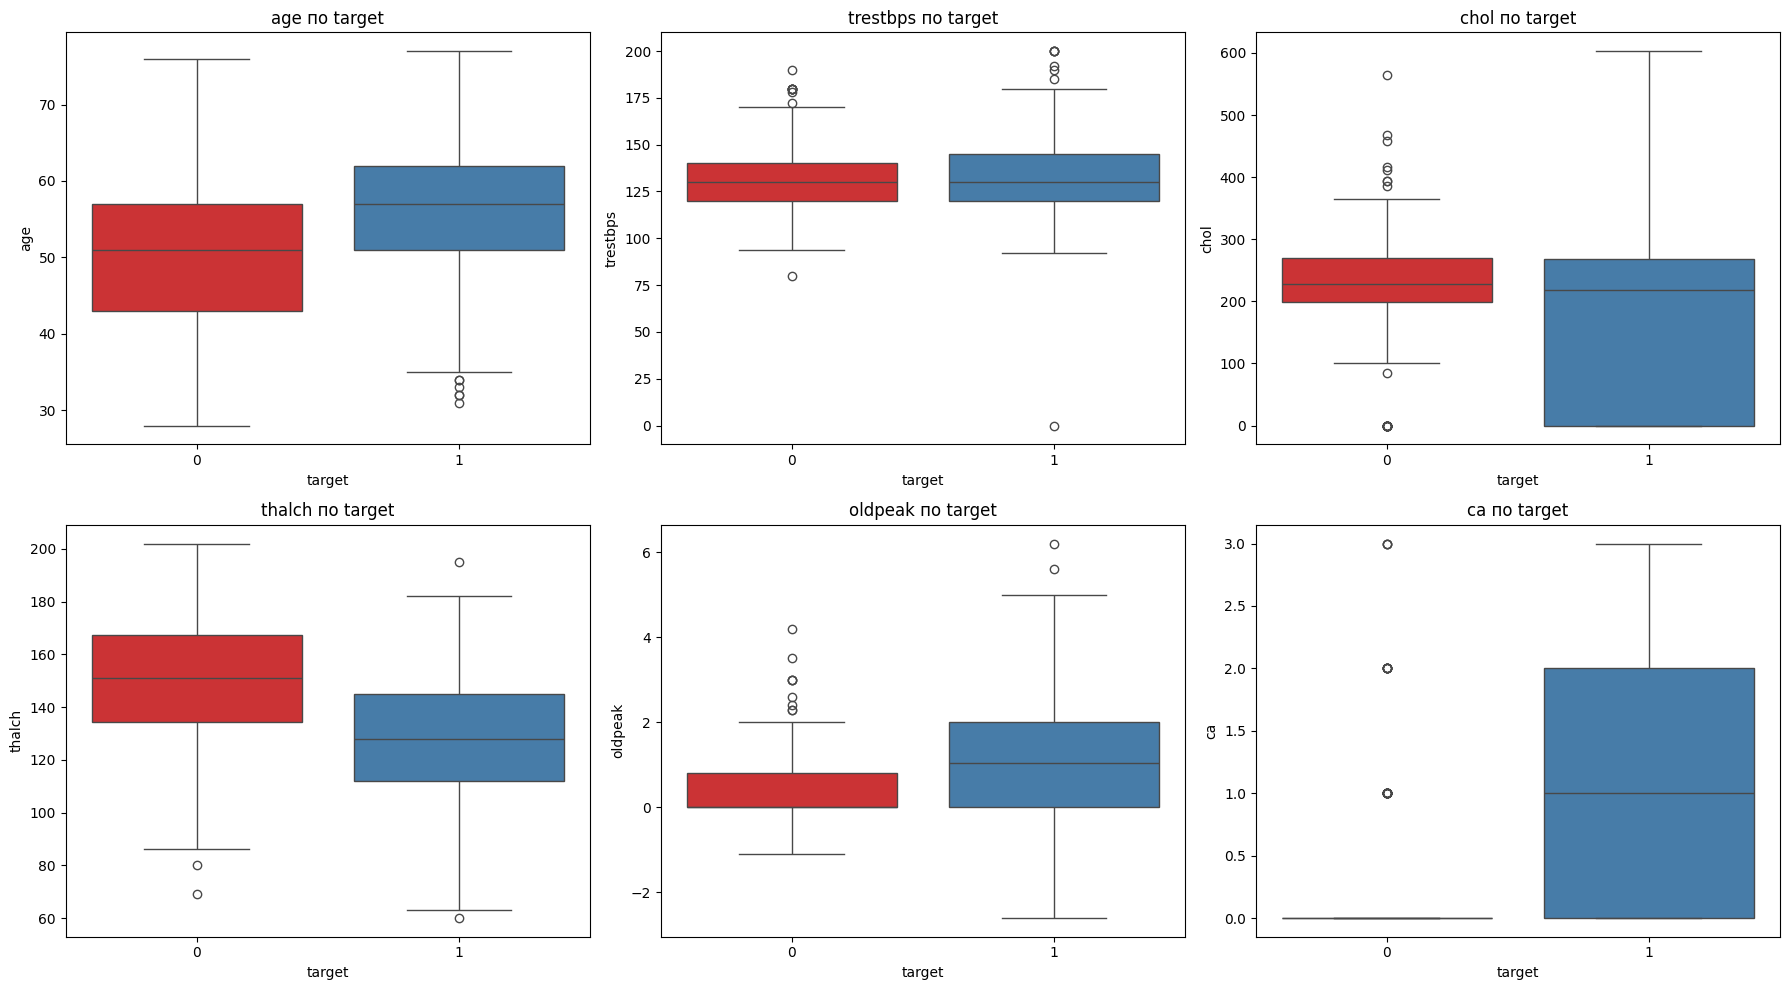

In [63]:
# Boxplot с раскраской по target (по одному, чтобы не смешивать масштабы)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(
        data=df,
        x='target',
        y=col,
        ax=ax,
        hue='target',        # ← явно указываем hue
        palette='Set1',
        legend=False         # ← отключаем легенду (она тут не нужна)
    )
    ax.set_title(f'{col} по target')
plt.tight_layout()
plt.show()

# 7. Анализ выбросов

In [64]:
# IQR
def outlier_report(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    return pd.Series({
        'lower': lower, 'upper': upper,
        'n_outliers': n_out,
        'pct_%': round(100 * n_out / s.notna().sum(), 2)
    })

for col in num_cols:
    print(col)
    print(outlier_report(df[col]))
    print()

age
lower         27.5
upper         79.5
n_outliers     0.0
pct_%          0.0
dtype: float64

trestbps
lower          90.00
upper         170.00
n_outliers     28.00
pct_%           3.25
dtype: float64

chol
lower          35.50
upper         407.50
n_outliers    183.00
pct_%          20.56
dtype: float64

thalch
lower          64.50
upper         212.50
n_outliers      2.00
pct_%           0.23
dtype: float64

oldpeak
lower         -2.25
upper          3.75
n_outliers    16.00
pct_%          1.86
dtype: float64

ca
lower         -1.50
upper          2.50
n_outliers    20.00
pct_%          6.47
dtype: float64



# 8. Углублённая корреляция

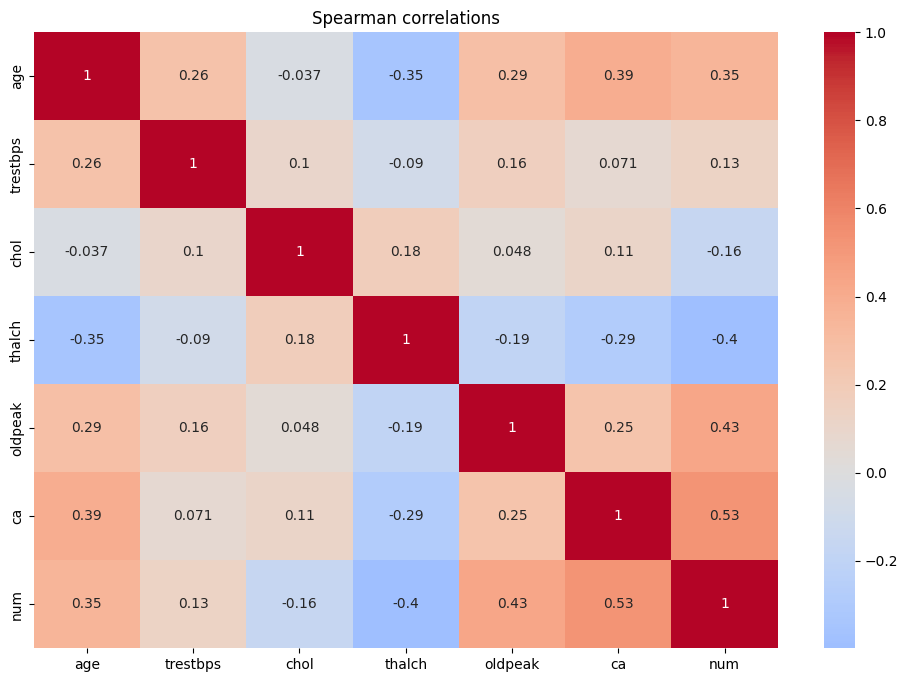

In [65]:
# Spearman — устойчив к выбросам и нелинейным монотонным связям
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols + ['num']].corr(method='spearman'),
            annot=True, cmap='coolwarm', center=0)
plt.title('Spearman correlations')
plt.show()

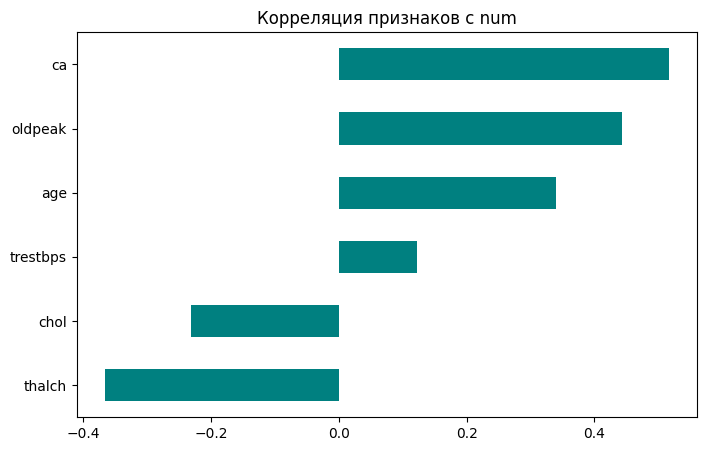

In [66]:
# Корреляция с целевой (топ-20)
corr_with_target = df[num_cols + ['num']].corr()['num'].drop('num').sort_values()
corr_with_target.plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('Корреляция признаков с num')
plt.show()

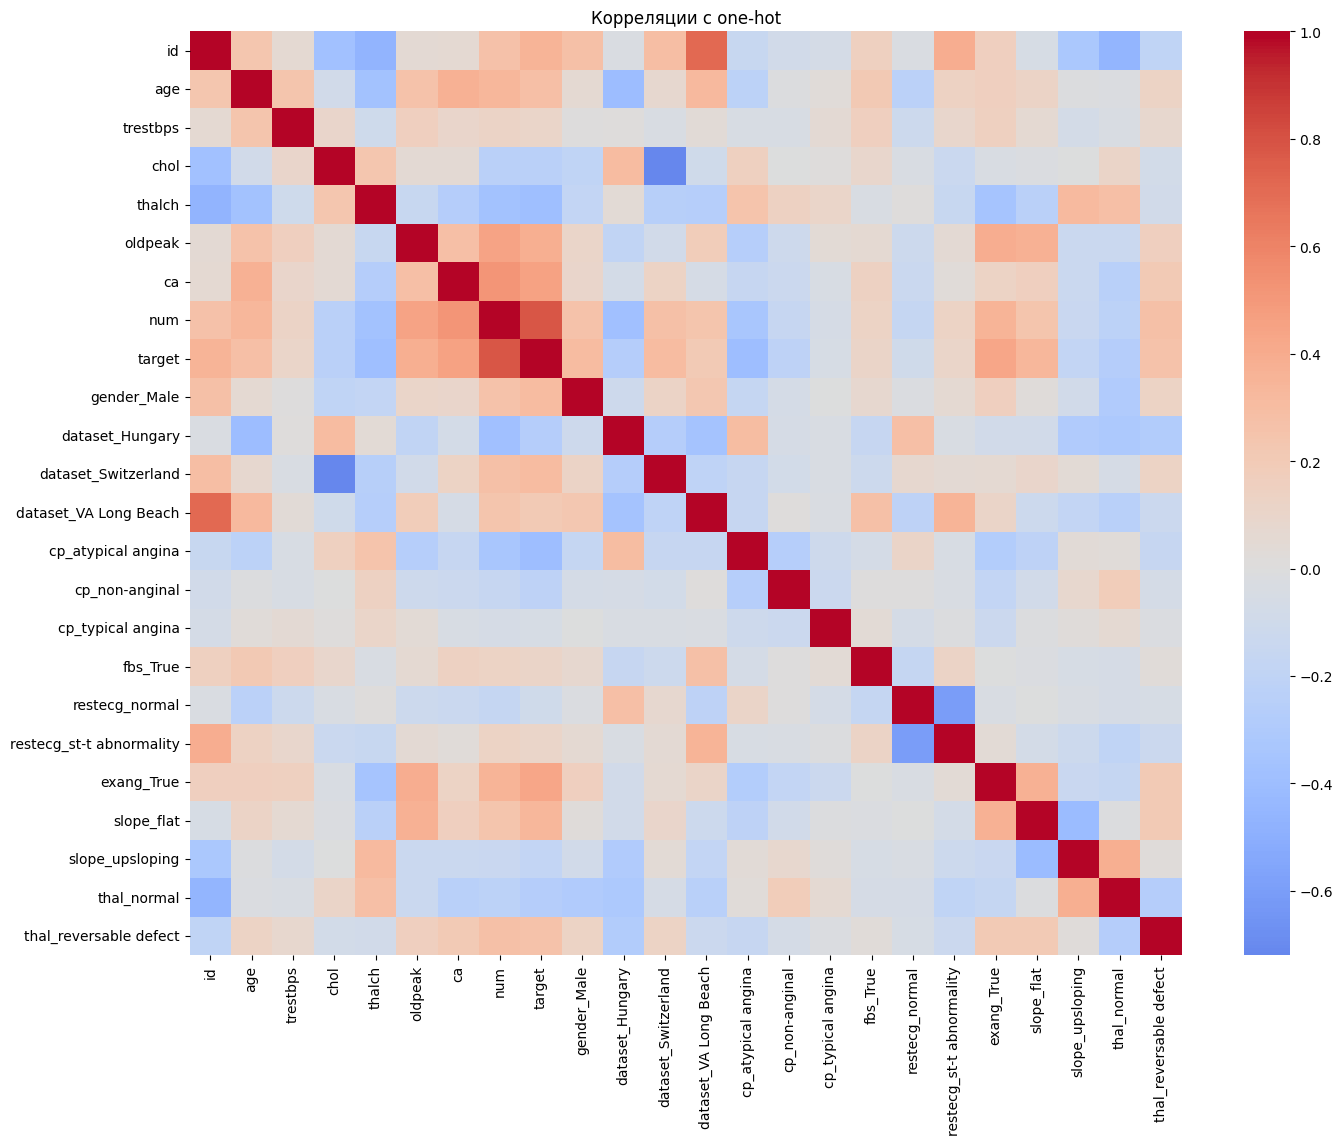

In [67]:
# После кодирования категориальных — полная корреляция
df_enc = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(16, 12))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0)
plt.title('Корреляции с one-hot')
plt.show()

# 9. Парный график

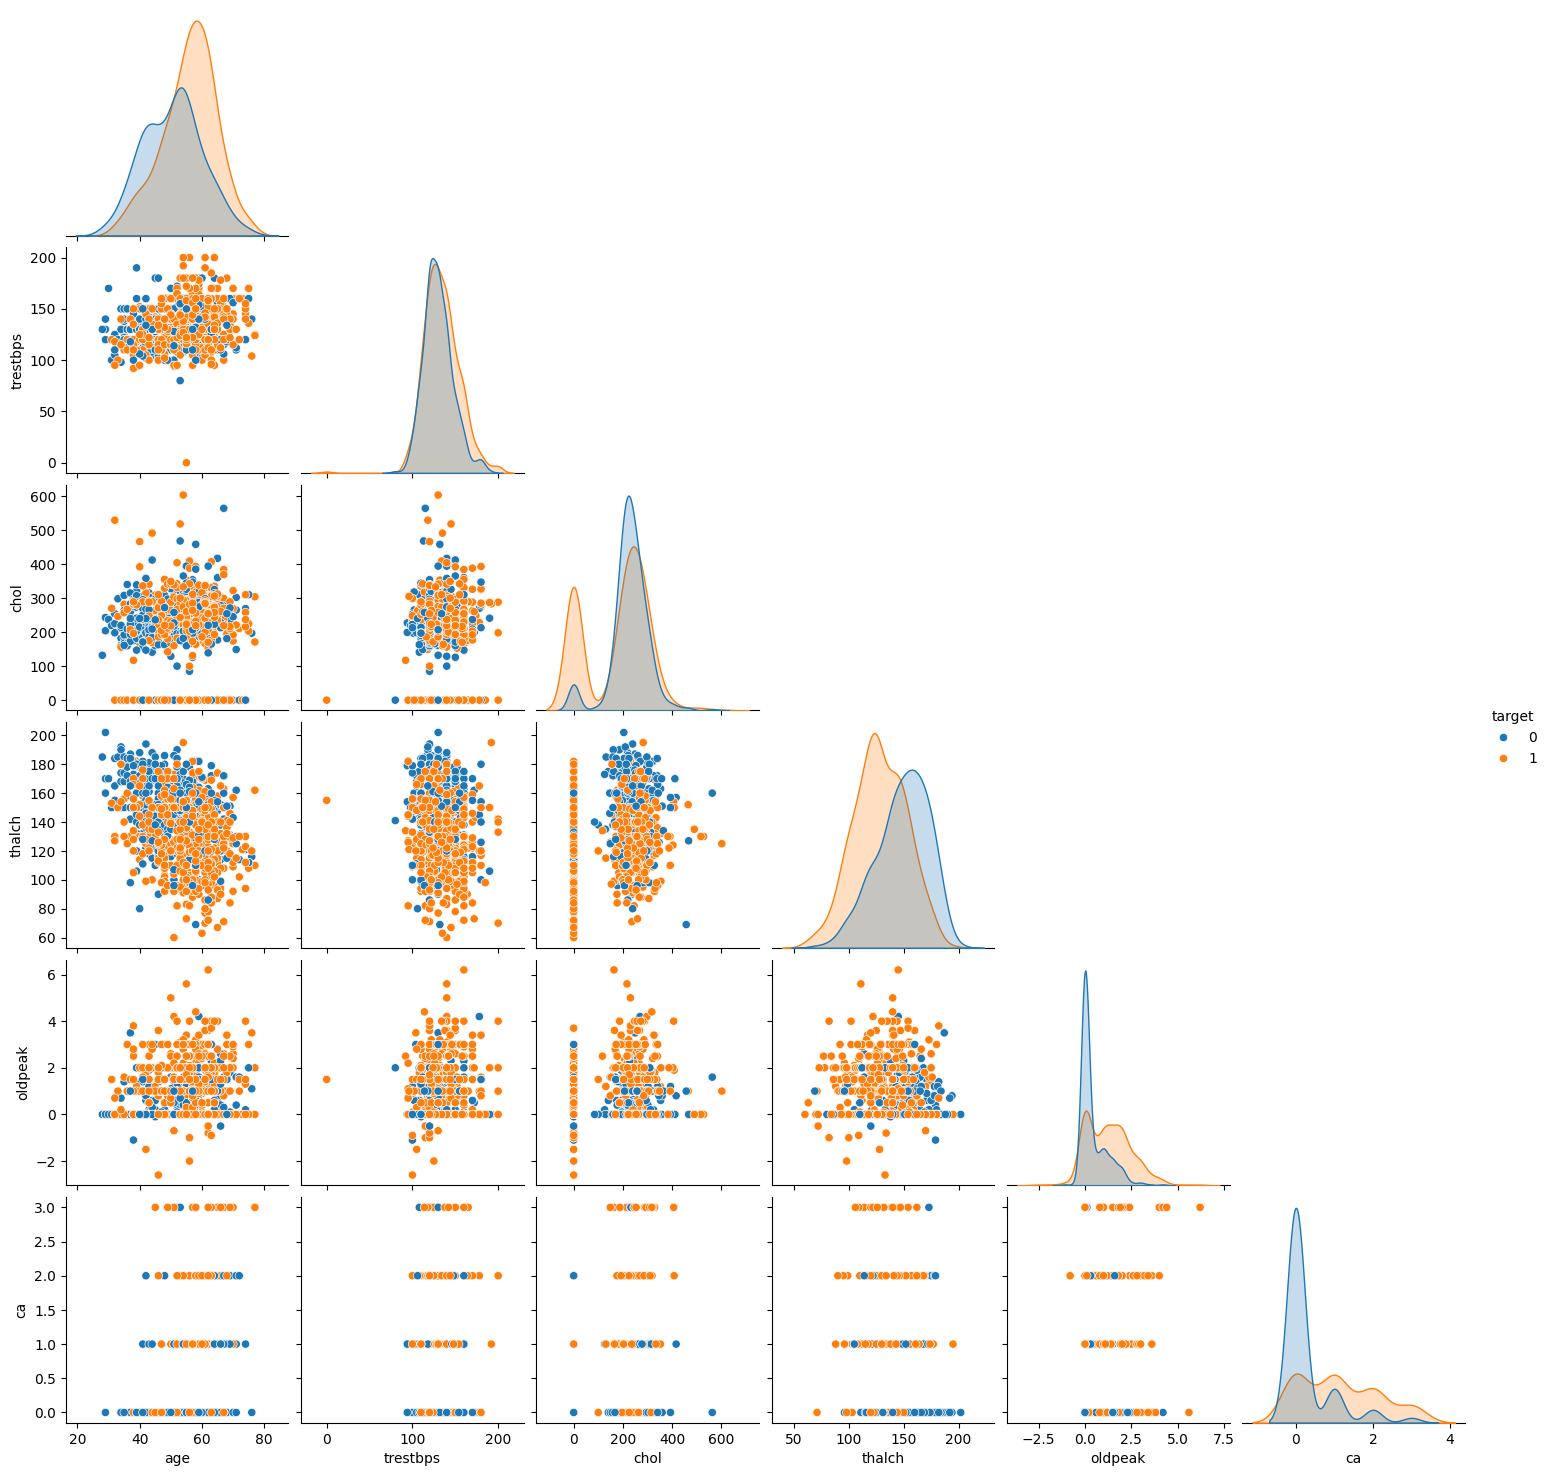

In [69]:
# Pairplot по числовым и target
sns.pairplot(df[num_cols + ['target']], hue='target', diag_kind='kde', corner=True)
plt.show()

# 10. Разрез по dataset — критично для этого набора

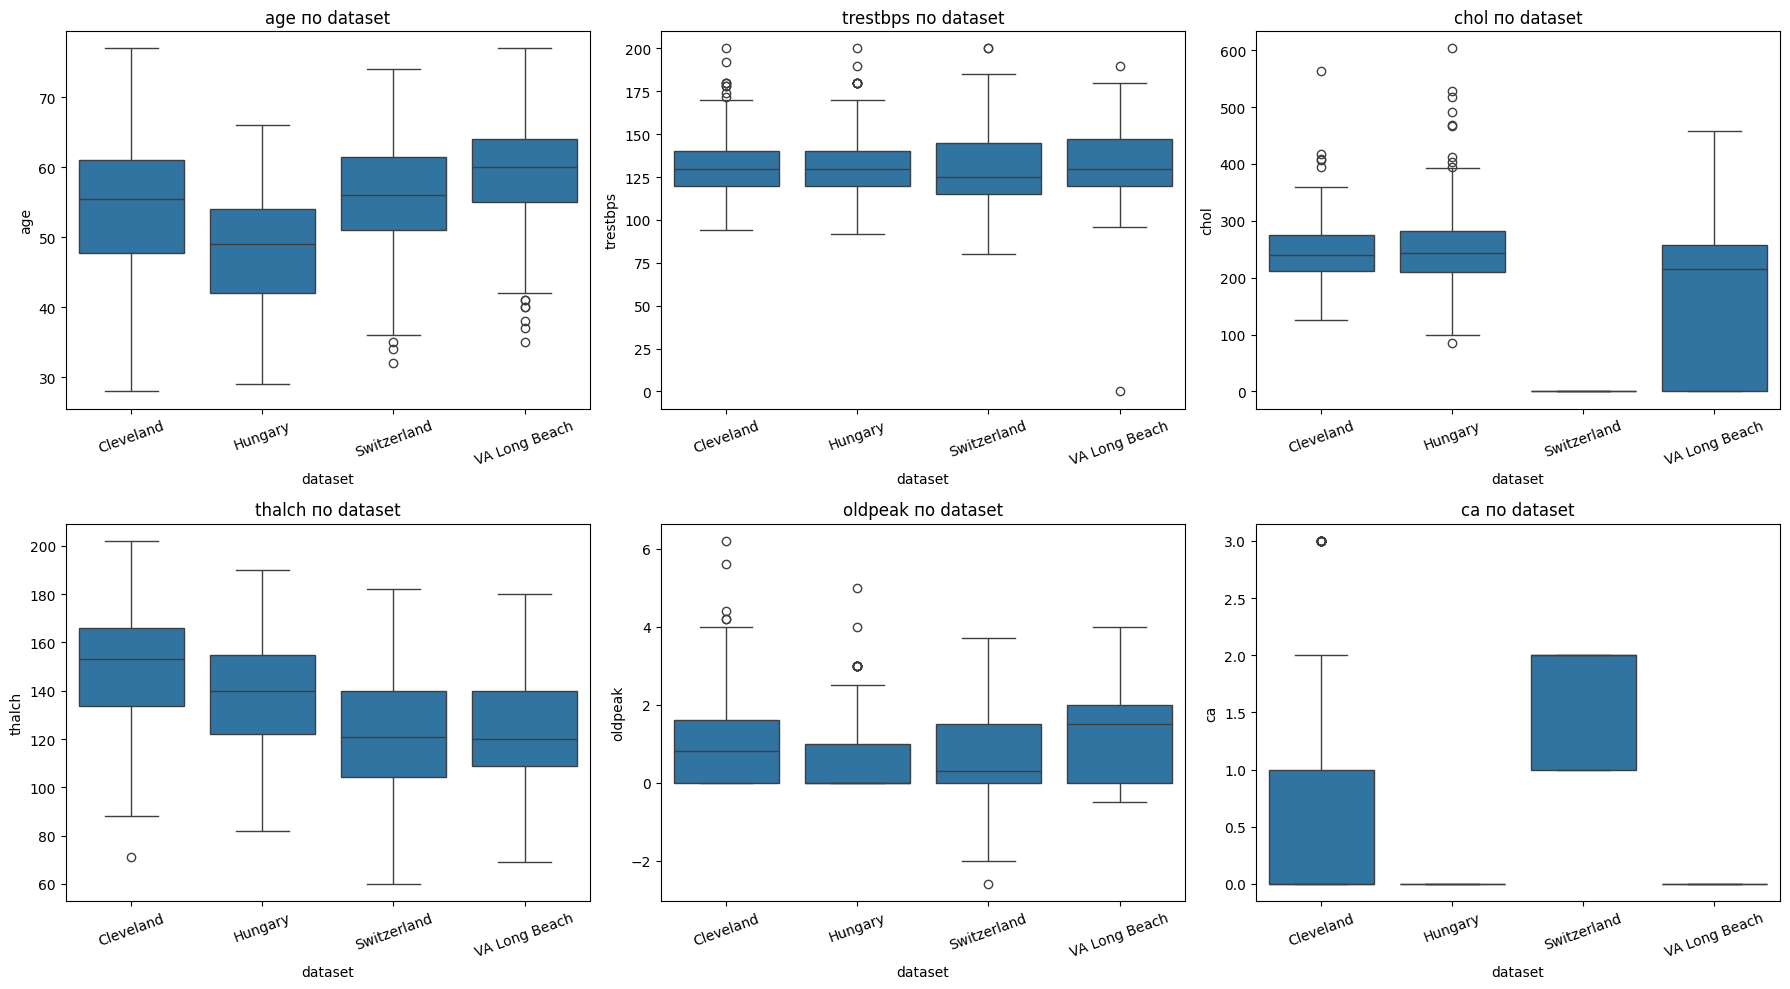

In [70]:
# Распределения признаков по источникам
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='dataset', y=col, ax=ax)
    ax.set_title(f'{col} по dataset')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [71]:
# Доля больных в каждом датасете
df.groupby('dataset')['target'].agg(['mean', 'count']).round(3)

,mean,count
dataset,,
Cleveland,0.457,304
Hungary,0.362,293
Switzerland,0.935,123
VA Long Beach,0.745,200


In [73]:
# Crosstab dataset vs num
pd.crosstab(df['dataset'], df['num'], normalize='index').round(3)

num,0,1,2,3,4
dataset,,,,,
Cleveland,0.543,0.181,0.118,0.115,0.043
Hungary,0.638,0.362,0.000,0.000,0.000
Switzerland,0.065,0.390,0.260,0.244,0.041
VA Long Beach,0.255,0.280,0.205,0.210,0.050


# 11. Интерактивные графики Plotly

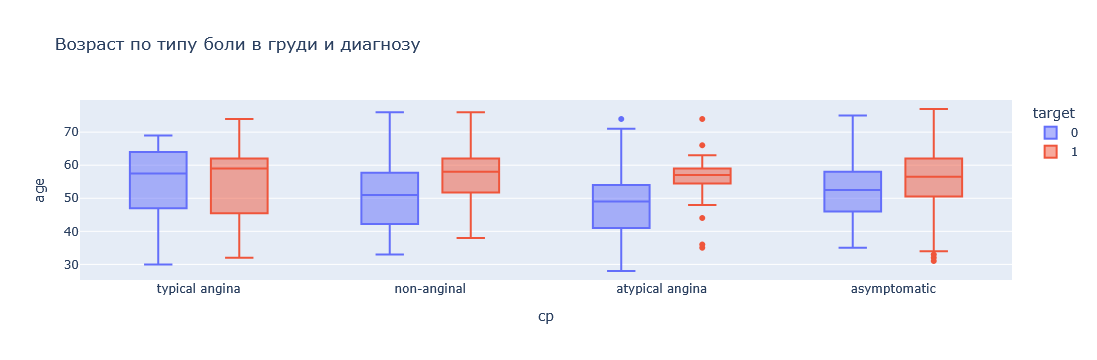

In [74]:
# Box plot по target и dataset
px.box(df, x='cp', y='age', color='target',
       title='Возраст по типу боли в груди и диагнозу').show()

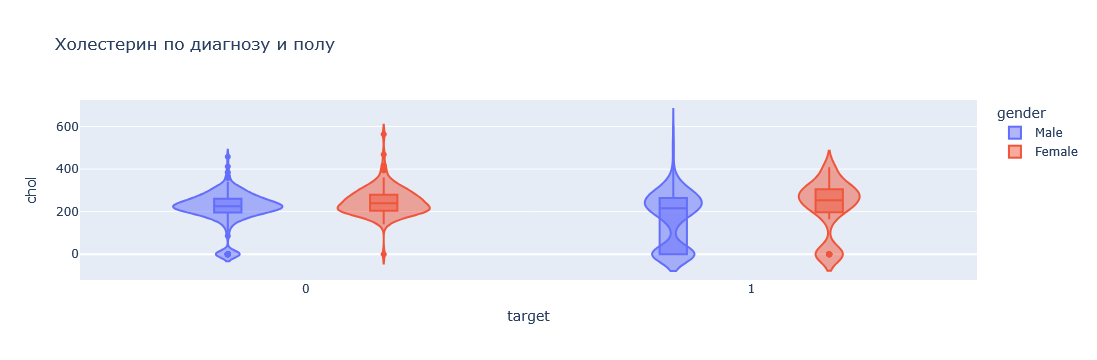

In [75]:
# Violin
px.violin(df, x='target', y='chol', color='gender', box=True,
          title='Холестерин по диагнозу и полу').show()

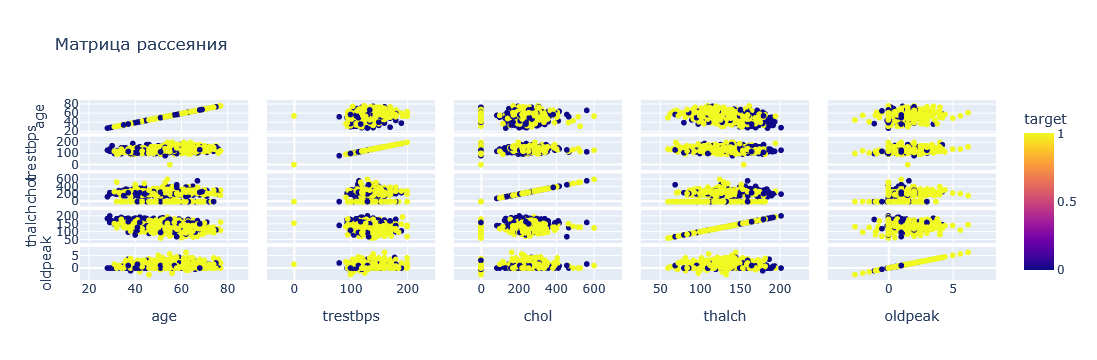

In [76]:
# Scatter matrix
px.scatter_matrix(df, dimensions=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'],
                  color='target', title='Матрица рассеяния').show()

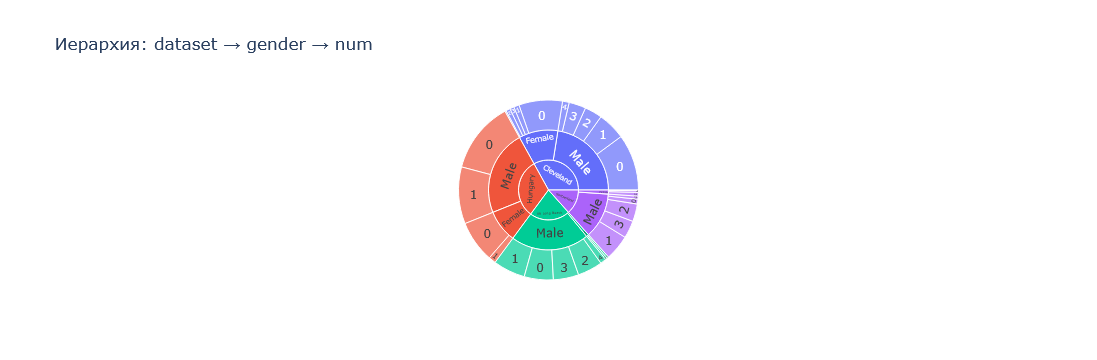

In [77]:
# Sunburst по категориям
px.sunburst(df, path=['dataset', 'gender', 'num'],
            title='Иерархия: dataset → gender → num').show()

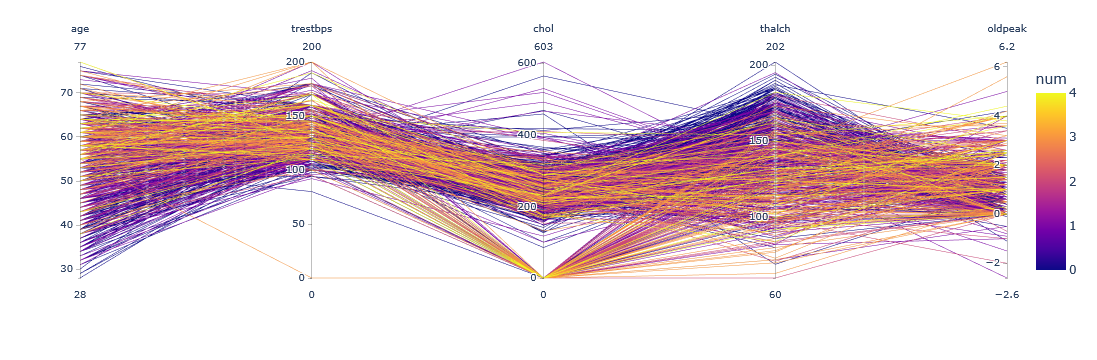

In [78]:
# Параллельные координаты
px.parallel_coordinates(df, color='num',
                        dimensions=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'])

# 12. Сводные таблицы

In [79]:
# Средние по классам
df.groupby('num')[num_cols].mean().round(1)

,age,trestbps,chol,thalch,oldpeak,ca
num,,,,,,
0,50.5,129.9,227.9,148.8,0.4,0.3
1,53.5,132.9,195.3,131.0,1.0,0.7
2,57.6,133.6,143.9,128.7,1.4,1.2
3,59.2,136.2,159.7,120.5,1.6,1.5
4,59.2,138.7,192.1,127.8,2.3,1.7


In [80]:
# Медианы
df.groupby('num')[num_cols].median()

,age,trestbps,chol,thalch,oldpeak,ca
num,,,,,,
0,51.0,130.0,228.0,151.0,0.0,0.0
1,55.0,130.0,229.0,130.0,1.0,1.0
2,58.0,134.0,193.0,130.0,1.5,1.0
3,60.0,135.0,213.0,120.0,1.5,2.0
4,59.0,136.0,225.0,125.0,2.5,2.0


In [81]:
# Crosstab gender × cp × target
pd.crosstab([df['gender'], df['cp']], df['target'], normalize='index').round(3)

target                      0      1
gender cp                           
Female asymptomatic     0.443  0.557
       atypical angina  0.934  0.066
       non-anginal      0.887  0.113
       typical angina   0.900  0.100
Male   asymptomatic     0.171  0.829
       atypical angina  0.823  0.177
       non-anginal      0.556  0.444
       typical angina   0.472  0.528

In [82]:
# Pivot: средний возраст по cp и target
df.pivot_table(index='cp', columns='target', values='age', aggfunc='mean').round(1)

target,0,1
cp,,
asymptomatic,52.3,55.7
atypical angina,48.2,56.0
non-anginal,51.0,57.4
typical angina,54.7,55.0


# 13. Статистические тесты

In [86]:
# t-test для числовых: различаются ли средние между target=0 и target=1
for col in num_cols:
    g0 = df.loc[df['target'] == 0, col].dropna()
    g1 = df.loc[df['target'] == 1, col].dropna()
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    print(f'{col}: t={t:.2f}, p={p:.4f}')

age: t=-8.86, p=0.0000
trestbps: t=-3.19, p=0.0015
chol: t=7.48, p=0.0000
thalch: t=12.63, p=0.0000
oldpeak: t=-12.76, p=0.0000
ca: t=-8.71, p=0.0000


In [87]:
# Chi-square для категориальных
for col in cat_cols:
    ct = pd.crosstab(df[col], df['target'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f'{col}: chi2={chi2:.2f}, p={p:.4f}, dof={dof}')

gender: chi2=85.36, p=0.0000, dof=1
dataset: chi2=157.06, p=0.0000, dof=3
cp: chi2=268.35, p=0.0000, dof=3
fbs: chi2=16.11, p=0.0001, dof=1
restecg: chi2=11.71, p=0.0029, dof=2
exang: chi2=184.02, p=0.0000, dof=1
slope: chi2=88.85, p=0.0000, dof=2
thal: chi2=109.05, p=0.0000, dof=2


# Сводка

In [89]:
# Краткая сводка по каждому классу
df.groupby('num').describe().T

num                    0           1           2           3           4
id     count  411.000000  265.000000  109.000000  107.000000   28.000000
       mean   355.257908  542.898113  554.449541  560.467290  477.714286
       std    226.418610  231.690577  286.881976  297.923579  334.005085
       min      1.000000    3.000000    2.000000    7.000000   25.000000
       25%    186.500000  503.000000  267.000000  219.000000  152.250000
...                  ...         ...         ...         ...         ...
target min      0.000000    1.000000    1.000000    1.000000    1.000000
       25%      0.000000    1.000000    1.000000    1.000000    1.000000
       50%      0.000000    1.000000    1.000000    1.000000    1.000000
       75%      0.000000    1.000000    1.000000    1.000000    1.000000
       max      0.000000    1.000000    1.000000    1.000000    1.000000

[64 rows x 5 columns]

In [90]:
# Проверка диапазонов (медицинская валидность)
print('age min/max:', df['age'].min(), df['age'].max())
print('trestbps min/max:', df['trestbps'].min(), df['trestbps'].max())
print('chol min/max:', df['chol'].min(), df['chol'].max())
print('oldpeak min/max:', df['oldpeak'].min(), df['oldpeak'].max())

age min/max: 28 77
trestbps min/max: 0.0 200.0
chol min/max: 0.0 603.0
oldpeak min/max: -2.6 6.2


In [91]:
# Аномалии: chol=0, trestbps=0 в Switzerland/VA Long Beach
df[(df['chol'] == 0) | (df['trestbps'] == 0)]

,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
597,598,32,Male,Switzerland,typical angina,95.0,0.0,NaN,normal,127.0,False,0.7,upsloping,NaN,NaN,1,1
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1,1
599,600,35,Male,Switzerland,asymptomatic,NaN,0.0,NaN,normal,130.0,True,NaN,NaN,NaN,reversable defect,3,1
600,601,36,Male,Switzerland,asymptomatic,110.0,0.0,NaN,normal,125.0,True,1.0,flat,NaN,fixed defect,1,1
601,602,38,Female,Switzerland,asymptomatic,105.0,0.0,NaN,normal,166.0,False,2.8,upsloping,NaN,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,819,43,Male,VA Long Beach,asymptomatic,122.0,0.0,False,normal,120.0,False,0.5,upsloping,NaN,NaN,1,1
819,820,63,Male,VA Long Beach,non-anginal,130.0,0.0,True,st-t abnormality,160.0,False,3.0,flat,NaN,NaN,0,0
822,823,48,Male,VA Long Beach,non-anginal,102.0,0.0,NaN,st-t abnormality,110.0,True,1.0,downsloping,NaN,NaN,1,1
839,840,56,Male,VA Long Beach,asymptomatic,NaN,0.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,1,1
